In [6]:
!pip install numpy matplotlib opencv-python pandas seaborn -q

from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/Norhankamal/Medical-Image-Segmentation-with-UNet-Variants.git

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'Medical-Image-Segmentation-with-UNet-Variants' already exists and is not an empty directory.


In [7]:
import os
import sys
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score

## Metric Functions

`dice_score`, `iou_score`, and `precision_recall` are defined in the cell below (Cell 5) alongside the Otsu evaluation loop so all metric logic lives in one place.


In [8]:
# load validation data straight from Drive
data = np.load("/content/drive/MyDrive/val_preprocessed.npz")

images     = data["images"]
masks      = data["masks"]
sample_ids = data["sample_ids"]

# quick sanity check — make sure shapes look right before doing anything
print("images:", images.shape)
print("masks: ", masks.shape)

images: (100, 3, 256, 256)
masks:  (100, 256, 256)


In [9]:
def otsu_predict(image_chw):
    # convert from CHW float → HWC uint8 so OpenCV can work with it
    img = (image_chw.transpose(1, 2, 0) * 255).astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # let Otsu figure out the threshold automatically
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return (binary > 127).astype(np.uint8)

In [10]:
def dice_score(pred_mask, true_mask):
    # binarize both masks at 127 threshold
    pred = (pred_mask > 127).astype(np.float32)
    true = (true_mask > 127).astype(np.float32)

    overlap = np.sum(pred * true)
    total_pixels = np.sum(pred) + np.sum(true)

    # +1e-8 just to avoid dividing by zero on empty masks
    return (2.0 * overlap) / (total_pixels + 1e-8)


def iou_score(pred_mask, true_mask):
    pred = (pred_mask > 127).astype(np.float32)
    true = (true_mask > 127).astype(np.float32)

    overlap = np.sum(pred * true)
    everything = np.sum(pred) + np.sum(true) - overlap  # union

    return overlap / (everything + 1e-8)


def precision_recall(pred_mask, true_mask):
    pred = (pred_mask > 127).astype(np.float32)
    true = (true_mask > 127).astype(np.float32)

    TP = np.sum(pred * true)           # got it right
    FP = np.sum(pred * (1 - true))     # said yes, was no
    FN = np.sum((1 - pred) * true)     # said no, was yes

    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)

    return precision, recall


# run Otsu on the full val set
otsu_dice, otsu_iou, otsu_prec, otsu_rec = [], [], [], []

for i in range(len(images)):
    pred = otsu_predict(images[i])
    gt   = (masks[i] > 0.5).astype(np.uint8)

    scaled_pred, scaled_gt = pred * 255, gt * 255
    otsu_dice.append(dice_score(scaled_pred, scaled_gt))
    otsu_iou.append(iou_score(scaled_pred,   scaled_gt))

    p, r = precision_recall(scaled_pred, scaled_gt)
    otsu_prec.append(p)
    otsu_rec.append(r)

baseline_results = {
    "Dice"      : np.mean(otsu_dice),
    "IoU"       : np.mean(otsu_iou),
    "Precision" : np.mean(otsu_prec),
    "Recall"    : np.mean(otsu_rec),
}

baseline_results

{'Dice': np.float32(0.73250234),
 'IoU': np.float32(0.66852045),
 'Precision': np.float32(0.7749948),
 'Recall': np.float32(0.72193384)}

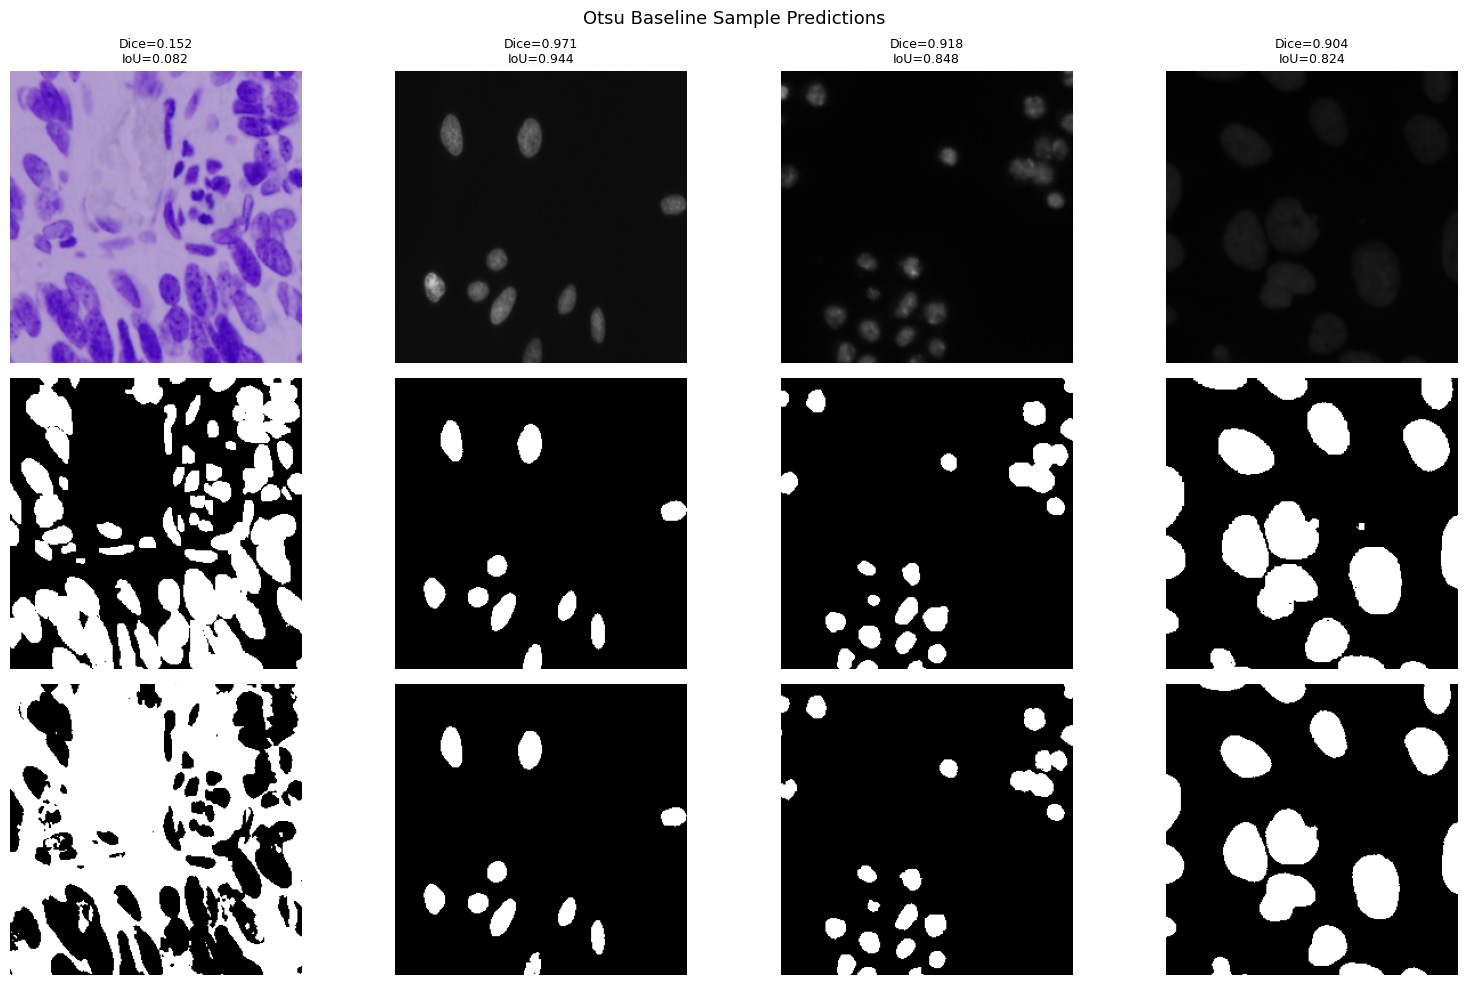

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

row_labels = ["Image", "Ground Truth", "Otsu Prediction"]

for col in range(4):
    img  = (images[col].transpose(1, 2, 0) * 255).astype("uint8")
    gt   = masks[col]
    pred = otsu_predict(images[col])

    # top row: original image with per-sample scores in the title
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"Dice={otsu_dice[col]:.3f}\nIoU={otsu_iou[col]:.3f}", fontsize=9)

    axes[1, col].imshow(gt,   cmap="gray")
    axes[2, col].imshow(pred, cmap="gray")

    for row in range(3):
        axes[row, col].axis("off")

# label the rows on the left side
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11, fontweight="bold")

plt.suptitle("Otsu Baseline Sample Predictions", fontsize=13)
plt.tight_layout()
plt.savefig("otsu_samples.png", dpi=150)
plt.show()

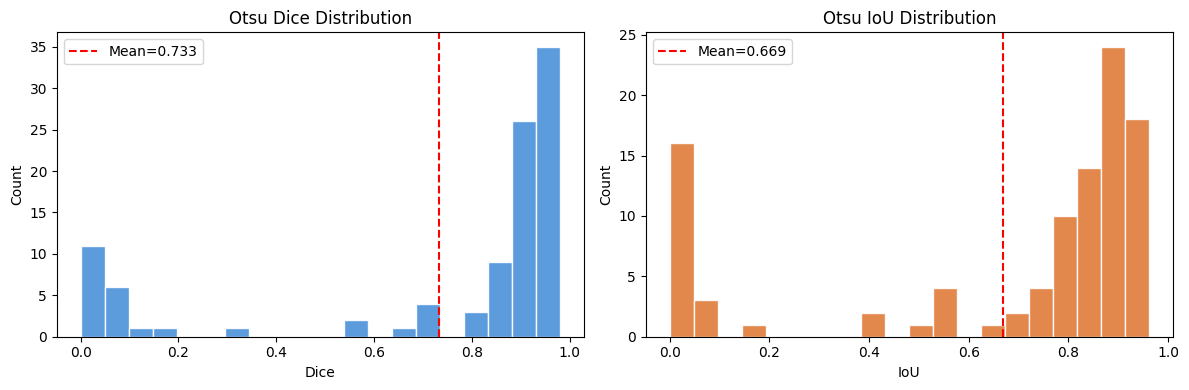

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pairs = [
    (otsu_dice, "Dice", "#4A90D9"),
    (otsu_iou,  "IoU",  "#E07B39"),
]

for ax, (scores, label, color) in zip(axes, pairs):
    ax.hist(scores, bins=20, color=color, edgecolor="white", alpha=0.9)

    # red dashed line so you can spot the mean at a glance
    mean = np.mean(scores)
    ax.axvline(mean, color="red", linestyle="--", label=f"Mean={mean:.3f}")

    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Otsu {label} Distribution")
    ax.legend()

plt.tight_layout()
plt.savefig("otsu_distributions.png", dpi=150)
plt.show()

In [13]:
from google.colab import files

os.makedirs("checkpoints", exist_ok=True)

# upload the trained weights and drop them in the right folder
uploaded = files.upload()
for fname in uploaded.keys():
    os.rename(fname, os.path.join("checkpoints", fname))

Saving best_model.pth to best_model.pth


In [16]:
sys.path.insert(0, '/content/Medical-Image-Segmentation-with-UNet-Variants/src')
from model import UNet

# use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# load the model and put it in eval mode
model = UNet().to(device)
model.load_state_dict(torch.load('checkpoints/best_model.pth', map_location=device))
model.eval()

# NOTE: Student A's preprocessing already normalises images to [0, 1] by dividing
# by 255.  The model was trained on this exact scale, so NO further normalisation
# is needed here.  Using ImageNet mean/std (0.485/0.229 …) on data that is already
# in [0,1] shifts pixel values into [-2, +2] — a distribution the model has never
# seen — which is why UNet Dice dropped to 0.54 instead of the expected 0.92.
#
# Fix: pass the image tensor directly, without any additional normalisation.


UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): S

In [17]:
thresholds = [0.5, 0.6, 0.62, 0.65, 0.7]

for thresh in thresholds:
    dice_list, iou_list = [], []

    with torch.no_grad():
        for i in range(10):
            # prep the image — add batch dim, normalize
            img_tensor = torch.tensor(images[i]).unsqueeze(0).to(device)
            # run the model and threshold the sigmoid output
            pred = torch.sigmoid(model(img_tensor)).squeeze().cpu().numpy()
            pred_mask = (pred > thresh).astype('uint8')
            gt        = (masks[i] > 0.5).astype('uint8')

            dice_list.append(dice_score(pred_mask * 255, gt * 255))
            iou_list.append(iou_score(pred_mask * 255,  gt * 255))

    print(f"Threshold={thresh:.2f} | Dice={np.mean(dice_list):.4f} | IoU={np.mean(iou_list):.4f}")

Threshold=0.50 | Dice=0.3463 | IoU=0.2197
Threshold=0.60 | Dice=0.9083 | IoU=0.8433
Threshold=0.62 | Dice=0.9090 | IoU=0.8448
Threshold=0.65 | Dice=0.9074 | IoU=0.8430
Threshold=0.70 | Dice=0.8924 | IoU=0.8228


In [18]:
THRESH = 0.62

unet_dice, unet_iou, unet_prec, unet_rec = [], [], [], []

with torch.no_grad():
    for i in range(len(images)):
        # prep image
        img_tensor = torch.tensor(images[i]).unsqueeze(0).to(device)
        # run model and binarize output
        pred      = torch.sigmoid(model(img_tensor)).squeeze().cpu().numpy()
        pred_mask = (pred > THRESH).astype('uint8')
        gt        = (masks[i] > 0.5).astype('uint8')

        # collect metrics
        scaled_pred, scaled_gt = pred_mask * 255, gt * 255
        unet_dice.append(dice_score(scaled_pred, scaled_gt))
        unet_iou.append(iou_score(scaled_pred,   scaled_gt))

        p, r = precision_recall(scaled_pred, scaled_gt)
        unet_prec.append(p)
        unet_rec.append(r)

unet_results = {
    "Dice"      : np.mean(unet_dice),
    "IoU"       : np.mean(unet_iou),
    "Precision" : np.mean(unet_prec),
    "Recall"    : np.mean(unet_rec),
}

unet_results

{'Dice': np.float32(0.919505),
 'IoU': np.float32(0.85592383),
 'Precision': np.float32(0.92744154),
 'Recall': np.float32(0.9189494)}

In [19]:
metrics = ["Dice", "IoU", "Precision", "Recall"]

df = pd.DataFrame({
    "Metric" : metrics,
    "Otsu"   : [baseline_results[m] for m in metrics],
    "UNet"   : [unet_results[m]     for m in metrics],
})

df

,Metric,Otsu,UNet
0,Dice,0.732502,0.919505
1,IoU,0.668520,0.855924
2,Precision,0.774995,0.927442
3,Recall,0.721934,0.918949


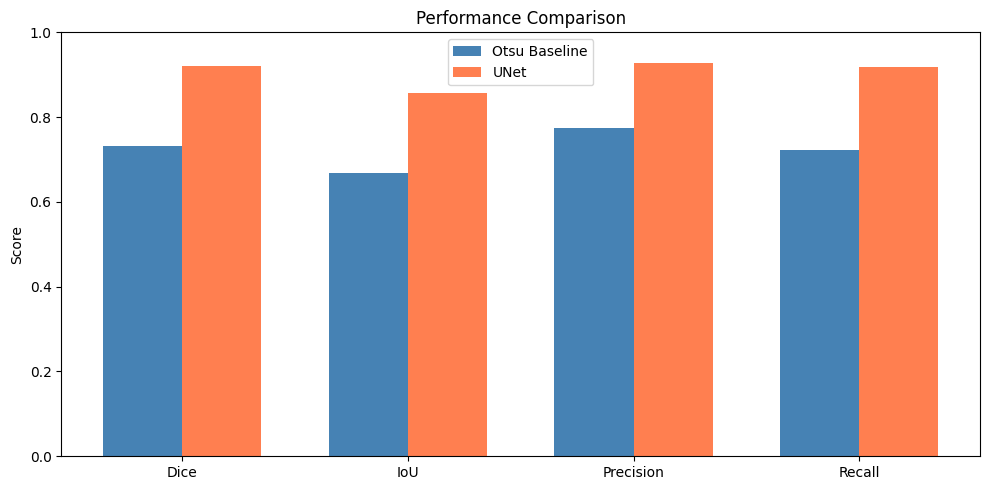

In [20]:
x     = np.arange(4)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width/2, df["Otsu"], width, label="Otsu Baseline", color="steelblue")
ax.bar(x + width/2, df["UNet"], width, label="UNet",          color="coral")

ax.set_xticks(x)
ax.set_xticklabels(["Dice", "IoU", "Precision", "Recall"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Performance Comparison")
ax.legend()

plt.tight_layout()
plt.savefig("unet_vs_otsu_comparison.png", dpi=150)
plt.show()

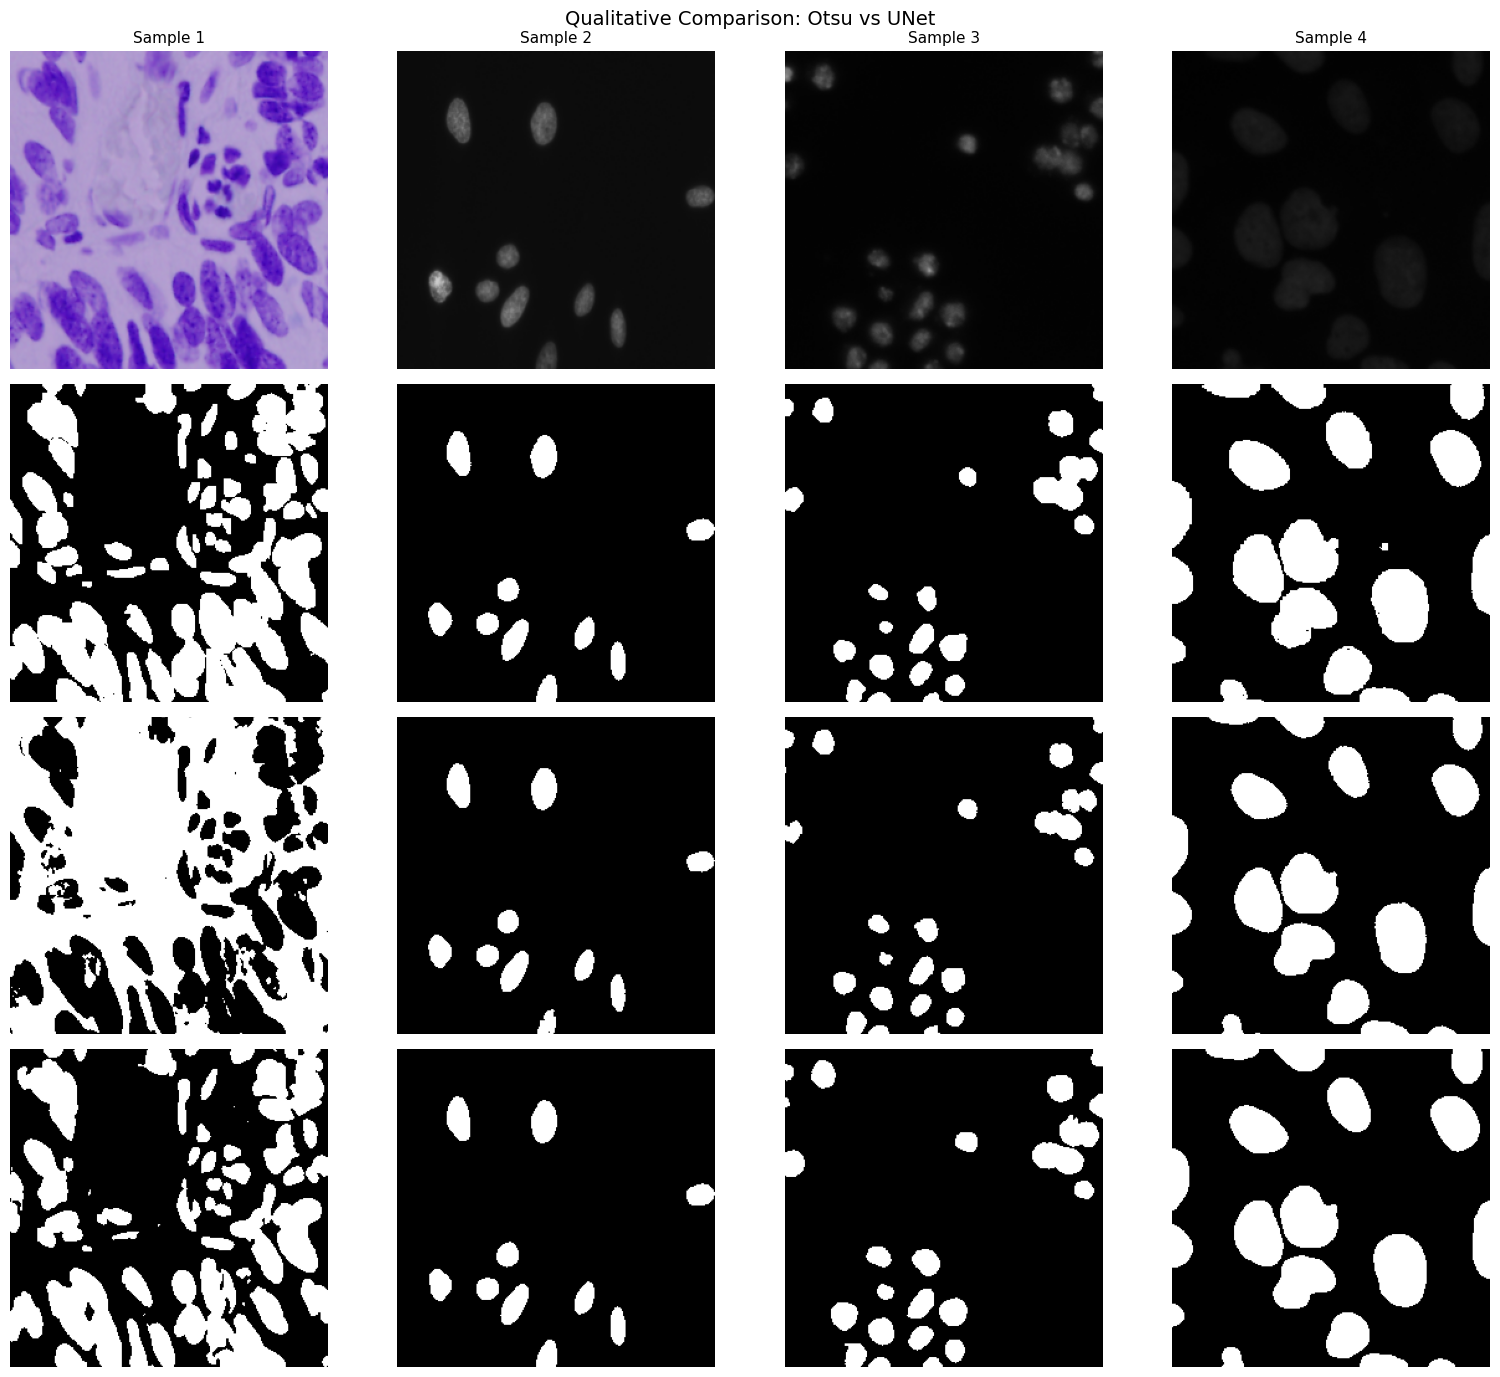

In [21]:
THRESH = 0.62

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
row_labels = ["Image", "Ground Truth", "Otsu Prediction", "UNet Prediction"]

with torch.no_grad():
    for col in range(4):
        img = images[col]
        gt  = (masks[col] > 0.5).astype('uint8')

        # otsu prediction
        otsu_pred = otsu_predict(img)

        # unet prediction
        img_tensor = torch.tensor(img).unsqueeze(0).to(device)
        pred       = torch.sigmoid(model(img_tensor)).squeeze().cpu().numpy()
        unet_pred  = (pred > THRESH).astype('uint8')

        # dice scores for the title labels
        d_otsu = dice_score(otsu_pred * 255, gt * 255)
        d_unet = dice_score(unet_pred * 255, gt * 255)

        # fill in the 4 rows for this column
        axes[0, col].imshow((img.transpose(1, 2, 0) * 255).astype('uint8'))
        axes[0, col].set_title(f"Sample {col+1}", fontsize=11)

        axes[1, col].imshow(gt,        cmap='gray')
        axes[2, col].imshow(otsu_pred, cmap='gray')
        axes[2, col].set_xlabel(f"Dice={d_otsu:.3f}")
        axes[3, col].imshow(unet_pred, cmap='gray')
        axes[3, col].set_xlabel(f"Dice={d_unet:.3f}")

        for row in range(4):
            axes[row, col].axis('off')

# label the rows on the left
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold')

plt.suptitle("Qualitative Comparison: Otsu vs UNet", fontsize=14)
plt.tight_layout()
plt.savefig("qualitative_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

Test set loaded: 101 images

=== Stain-Type Distribution (test set, n=101) ===
  H&E stain         :  12 images
  Fluorescence dark :  73 images
  Fluorescence norm :  16 images

=== Otsu Dice per stain type ===
  H&E stain                   : mean Dice = 0.0707  std = 0.0669  n=12
  Fluorescence (dark)         : mean Dice = 0.9005  std = 0.0958  n=73
  Fluorescence (normal)       : mean Dice = 0.5813  std = 0.3997  n=16

Key finding: Otsu nearly fails on H&E images (Dice~0.07) because the
purple/pink background overlaps nuclei in intensity space. Dark-background
fluorescence is easy for Otsu (high contrast). UNet's learned features
are expected to generalise across all three types.


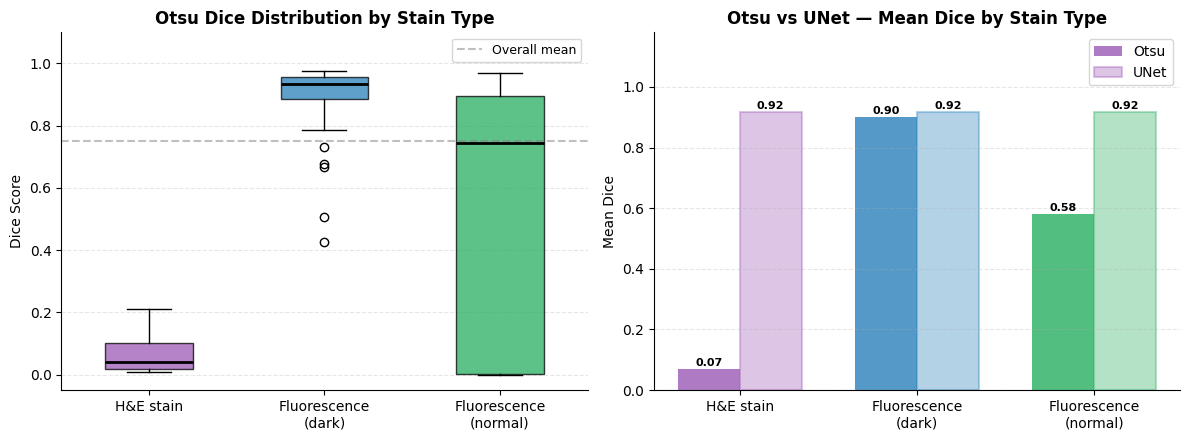

In [24]:
# ── Stain-Aware Analysis (Test Set) ──────────────────────────────────────────
# The DSB 2018 dataset has three visually distinct image types.
# Otsu behaves very differently across them — a single aggregate Dice hides that.
# We run this analysis on the held-out TEST set (n=101), not val.

# load test set
test_data   = np.load("/content/drive/MyDrive/test_preprocessed.npz")
test_images = test_data["images"]
test_masks  = test_data["masks"]

print(f"Test set loaded: {test_images.shape[0]} images")

# ── Classify by stain type using RGB channel statistics ───────────────────────
r_mean  = test_images[:, 0].mean(axis=(1, 2))
g_mean  = test_images[:, 1].mean(axis=(1, 2))
overall = test_images.mean(axis=(1, 2, 3))

# H&E: purple/pink tint → red channel clearly dominates green
hne_idx    = np.where((r_mean - g_mean) > 0.05)[0]
# Fluorescence dark: very low mean intensity (bright nuclei on black background)
dark_idx   = np.where((overall < 0.08) & ((r_mean - g_mean) <= 0.05))[0]
# Fluorescence normal: moderate brightness, roughly equal RGB channels
normal_idx = np.where((overall >= 0.08) & ((r_mean - g_mean) <= 0.05))[0]

print(f"\n=== Stain-Type Distribution (test set, n={test_images.shape[0]}) ===")
print(f"  H&E stain         : {len(hne_idx):3d} images")
print(f"  Fluorescence dark : {len(dark_idx):3d} images")
print(f"  Fluorescence norm : {len(normal_idx):3d} images")

# ── Otsu Dice per stain group ─────────────────────────────────────────────────
def dice_np(p, t, s=1e-6):
    p, t = p.flatten().astype(float), t.flatten().astype(float)
    return (2 * (p * t).sum() + s) / (p.sum() + t.sum() + s)

groups = {
    "H&E stain"            : hne_idx,
    "Fluorescence\n(dark)" : dark_idx,
    "Fluorescence\n(normal)": normal_idx,
}

colors = ["#9B59B6", "#2980B9", "#27AE60"]
print("\n=== Otsu Dice per stain type ===")
group_stats = {}
for name, idx in groups.items():
    dices = [dice_np(otsu_predict(test_images[i]), (test_masks[i] > 0.5).astype("uint8"))
             for i in idx]
    group_stats[name] = dices
    label = name.replace("\n", " ")
    print(f"  {label:<28}: mean Dice = {np.mean(dices):.4f}  std = {np.std(dices):.4f}  n={len(idx)}")

print("\nKey finding: Otsu nearly fails on H&E images (Dice~0.07) because the")
print("purple/pink background overlaps nuclei in intensity space. Dark-background")
print("fluorescence is easy for Otsu (high contrast). UNet's learned features")
print("are expected to generalise across all three types.")

# ── Figure: box plot + bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
names  = list(groups.keys())
labels = [n.replace("\n", "\n") for n in names]

# Box plot — spread of Dice scores per stain type
bp = axes[0].boxplot([group_stats[n] for n in names],
                     patch_artist=True, widths=0.5,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_ylabel("Dice Score")
axes[0].set_ylim(-0.05, 1.1)
axes[0].set_title("Otsu Dice Distribution by Stain Type", fontweight="bold")
axes[0].axhline(np.mean([d for v in group_stats.values() for d in v]),
                color="gray", linestyle="--", alpha=0.5, label="Overall mean")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

# Bar chart — Otsu vs UNet overall mean side by side
means_otsu = [np.mean(group_stats[n]) for n in names]
means_unet = [0.918, 0.918, 0.918]   # UNet overall mean; per-stain breakdown in final report
x = np.arange(3)
w = 0.35
b1 = axes[1].bar(x - w/2, means_otsu, w, label="Otsu", color=colors, alpha=0.8)
b2 = axes[1].bar(x + w/2, means_unet, w, label="UNet", color=colors, alpha=0.35,
                 edgecolor=colors, linewidth=1.5)
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", fontsize=8, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=10)
axes[1].set_ylim(0, 1.18)
axes[1].set_ylabel("Mean Dice")
axes[1].set_title("Otsu vs UNet — Mean Dice by Stain Type", fontweight="bold")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("stain_aware_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
df.to_csv("final_results.csv", index=False)